In [1]:
# %matplotlib ipympl

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import pyPPG
import pyPPG.example
import scipy.io
import scipy.signal
from matplotlib import pyplot as plt

from config import Config as c

In [3]:
df_subjects = pd.read_csv(c.SUBJECTS_PATH)

In [4]:
df_subjects['patient_file'] = df_subjects.apply(lambda r: c.PPG_DIR / f'p{r["subject_id"]:06d}_{r["segment_id"]}.mat', axis=1)

In [10]:
subject_id, category, patient_file = df_subjects.loc[1, ['subject_id', 'class', 'patient_file']]

In [6]:
fs = 125

In [11]:
mat = scipy.io.loadmat(patient_file)

In [12]:
t = mat['time'].squeeze()
ppg_raw = mat['data'].squeeze()

In [9]:
b, a = scipy.signal.cheby2(4, 20, 30, fs=fs)
ppg_cheby = scipy.signal.filtfilt(b, a, ppg_raw)

In [10]:
b, a = scipy.signal.butter(4, 30, fs=fs)
ppg_butter = scipy.signal.filtfilt(b, a, ppg_raw)

In [12]:
ppg = ppg_raw
# ppg = ppg_cheby
# ppg = ppg_butter
scipy.io.savemat(f'data/ppg/{patient_file.name}', {'Fs': fs, 'Data': ppg_raw})

load: 0.9495100002823165


/home/thulio/.venvs/rsch/lib/python3.12/site-packages/pyPPG/fiducials.py:65: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  ppg_fp[keys[n]][0:len(temp_val)]=temp_val
/home/thulio/.venvs/rsch/lib/python3.12/site-packages/pyPPG/fiducials.py:65:

Fiducial points:
                    on     sp     dn     dp    off      u      v      w      a  \
Index of pulse                                                                  
0                   0     29     50   <NA>     74     22     36     59     15   
1                  74     91    117    121    136     83     98    120     77   
2                 136    153    187   <NA>    196    145    160    179    139   
3                 196    214    240   <NA>    258    206    222    243    200   
4                 258    276    303   <NA>    320    267    283    305    261   
...               ...    ...    ...    ...    ...    ...    ...    ...    ...   
596             36857  36874  36901  36904  36919  36867  36881  36903  36860   
597             36919  36936  36965   <NA>  36980  36928  36943  36966  36922   
598             36980  36998  37025  37027  37043  36990  37005  37026  36984   
599             37043  37060  37088   <NA>  37104  37052  37067  37090  37046   
600       

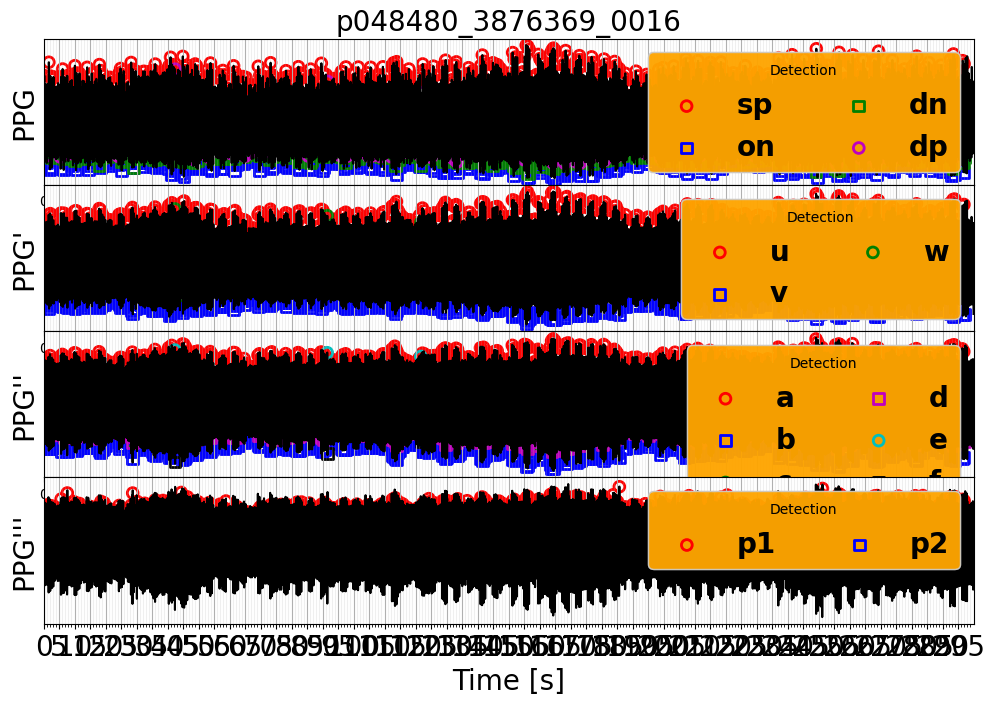

Figure has been saved in the "temp_dir/PPG_Figures/".
Statistics of the biomarkers:
ppg_sig 
                       Tpi         Tpp       Tsys       Tdia        Tsp  \
Statistics                                                               
mean             0.494720    0.494573   0.358347   0.129195   0.138720   
median           0.496000    0.496000   0.352000   0.128000   0.136000   
std              0.035808    0.035414   0.027790   0.026386   0.006202   
percentile_25    0.488000    0.488000   0.344000   0.120000   0.136000   
percentile_75    0.496000    0.496000   0.368000   0.128000   0.144000   
iqr              0.008000    0.008000   0.024000   0.008000   0.008000   
skew            12.996142   13.414678   2.916168   7.758265   5.853262   
kurtosis       175.475080  183.664551  12.914292  65.296718  83.627430   
mad              0.008339    0.007447   0.017229   0.009899   0.004363   

                     Tdp     deltaT         Tsw10         Tsw25         Tsw33  \
Statistics

In [14]:
s, fp, bm = pyPPG.example.ppg_example(
    data_path=f'data/test/{patient_file.name}',
    # filtering=False,
    filtering=True,
    # fL=0,
    # fH=30,
    # plotfig=False,
    # savefig=False,
    # savedata=False
)

In [15]:
fp.get_fp()

,on,sp,dn,dp,off,u,v,w,a,b,c,d,e,f,p1,p2
Index of pulse,,,,,,,,,,,,,,,,
0,0,29,50,<NA>,74,22,36,59,15,26,31,31,46,66,31,52
1,74,91,117,121,136,83,98,120,77,88,93,93,107,128,93,113
2,136,153,187,<NA>,196,145,160,179,139,151,156,156,168,179,156,174
3,196,214,240,<NA>,258,206,222,243,200,211,216,216,231,250,216,236
4,258,276,303,<NA>,320,267,283,305,261,273,278,278,291,312,278,299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
596,36857,36874,36901,36904,36919,36867,36881,36903,36860,36872,36877,36877,36890,36911,36877,36898
597,36919,36936,36965,<NA>,36980,36928,36943,36966,36922,36934,36939,36939,36950,36973,36939,36960
598,36980,36998,37025,37027,37043,36990,37005,37026,36984,36996,37001,37001,37013,37034,37001,37022


In [16]:
fp.get_fp().isna().sum()

on       0
sp       0
dn       0
dp     340
off      0
u        0
v        0
w        0
a        0
b        0
c        0
d        0
e        0
f        0
p1       0
p2       0
dtype: int64

In [17]:
bm.get_bm()

,bm_defs,bm_vals,bm_stats
ppg_sig,name ...,name TimeStamp Tpi Tpp Tsys...,Tpi Tpp Ts...
sig_ratios,name \ No. biomarker...,name TimeStamp IPR Tsys/Td...,IPR Tsys/Tdia Tpw25/Tp...
ppg_derivs,name ...,name TimeStamp Tu Tv Tw...,Tu Tv T...
derivs_ratios,name \ No. biomarkers ...,name TimeStamp Tu/Tpi Tv/Tpi ...,Tu/Tpi Tv/Tpi Tw/Tpi...


In [18]:
bm.bm_defs

{'ppg_sig':                   name                                         definition  \
 No. biomarkers                                                              
 1                  Tpi  Pulse interval, the time between the pulse ons...   
 2                  Tpp  Peak-to-peak interval, the time between two co...   
 3                 Tsys  Systolic time, the time between the pulse onse...   
 4                 Tdia  Diastolic time, the time is between the dicrot...   
 5                  Tsp  Systolic peak time, the time between the pulse...   
 6                  Tdp  Diastolic peak time, the time between the puls...   
 7               deltaT  Time delay, the time between the systolic peak...   
 8                Tsw10  Systolic width, the width at 10% of the systol...   
 9                Tsw25  Systolic width, the width at 25% of the systol...   
 10               Tsw33  Systolic width, the width at 33% of the systol...   
 11               Tsw50  Systolic width, the width at

In [19]:
bm.bm_stats

{'ppg_sig':                       Tpi         Tpp       Tsys       Tdia        Tsp  \
 Statistics                                                               
 mean             0.494720    0.494573   0.358347   0.129195   0.138720   
 median           0.496000    0.496000   0.352000   0.128000   0.136000   
 std              0.035808    0.035414   0.027790   0.026386   0.006202   
 percentile_25    0.488000    0.488000   0.344000   0.120000   0.136000   
 percentile_75    0.496000    0.496000   0.368000   0.128000   0.144000   
 iqr              0.008000    0.008000   0.024000   0.008000   0.008000   
 skew            12.996142   13.414678   2.916168   7.758265   5.853262   
 kurtosis       175.475080  183.664551  12.914292  65.296718  83.627430   
 mad              0.008339    0.007447   0.017229   0.009899   0.004363   
 
                      Tdp     deltaT         Tsw10         Tsw25         Tsw33  \
 Statistics                                                                     

In [20]:
bm.bm_vals

{'ppg_sig': name            TimeStamp    Tpi    Tpp   Tsys   Tdia    Tsp    Tdp  deltaT  \
 Index of pulse                                                                
 1                       0  0.592  0.496  0.400    NaN  0.232    NaN     NaN   
 2                      74  0.496  0.496  0.344  0.120  0.136  0.376   0.240   
 3                     136  0.480  0.488  0.408    NaN  0.136    NaN     NaN   
 4                     196  0.496  0.496  0.352    NaN  0.144    NaN     NaN   
 5                     258  0.496  0.496  0.360    NaN  0.144    NaN     NaN   
 ...                   ...    ...    ...    ...    ...    ...    ...     ...   
 596                 36795  0.496  0.496  0.344  0.120  0.136  0.376   0.240   
 597                 36857  0.496  0.496  0.352  0.120  0.136  0.376   0.240   
 598                 36919  0.488  0.496  0.368    NaN  0.136    NaN     NaN   
 599                 36980  0.504  0.496  0.360  0.128  0.144  0.376   0.232   
 600                 37043  0

(0.0, 10.0)

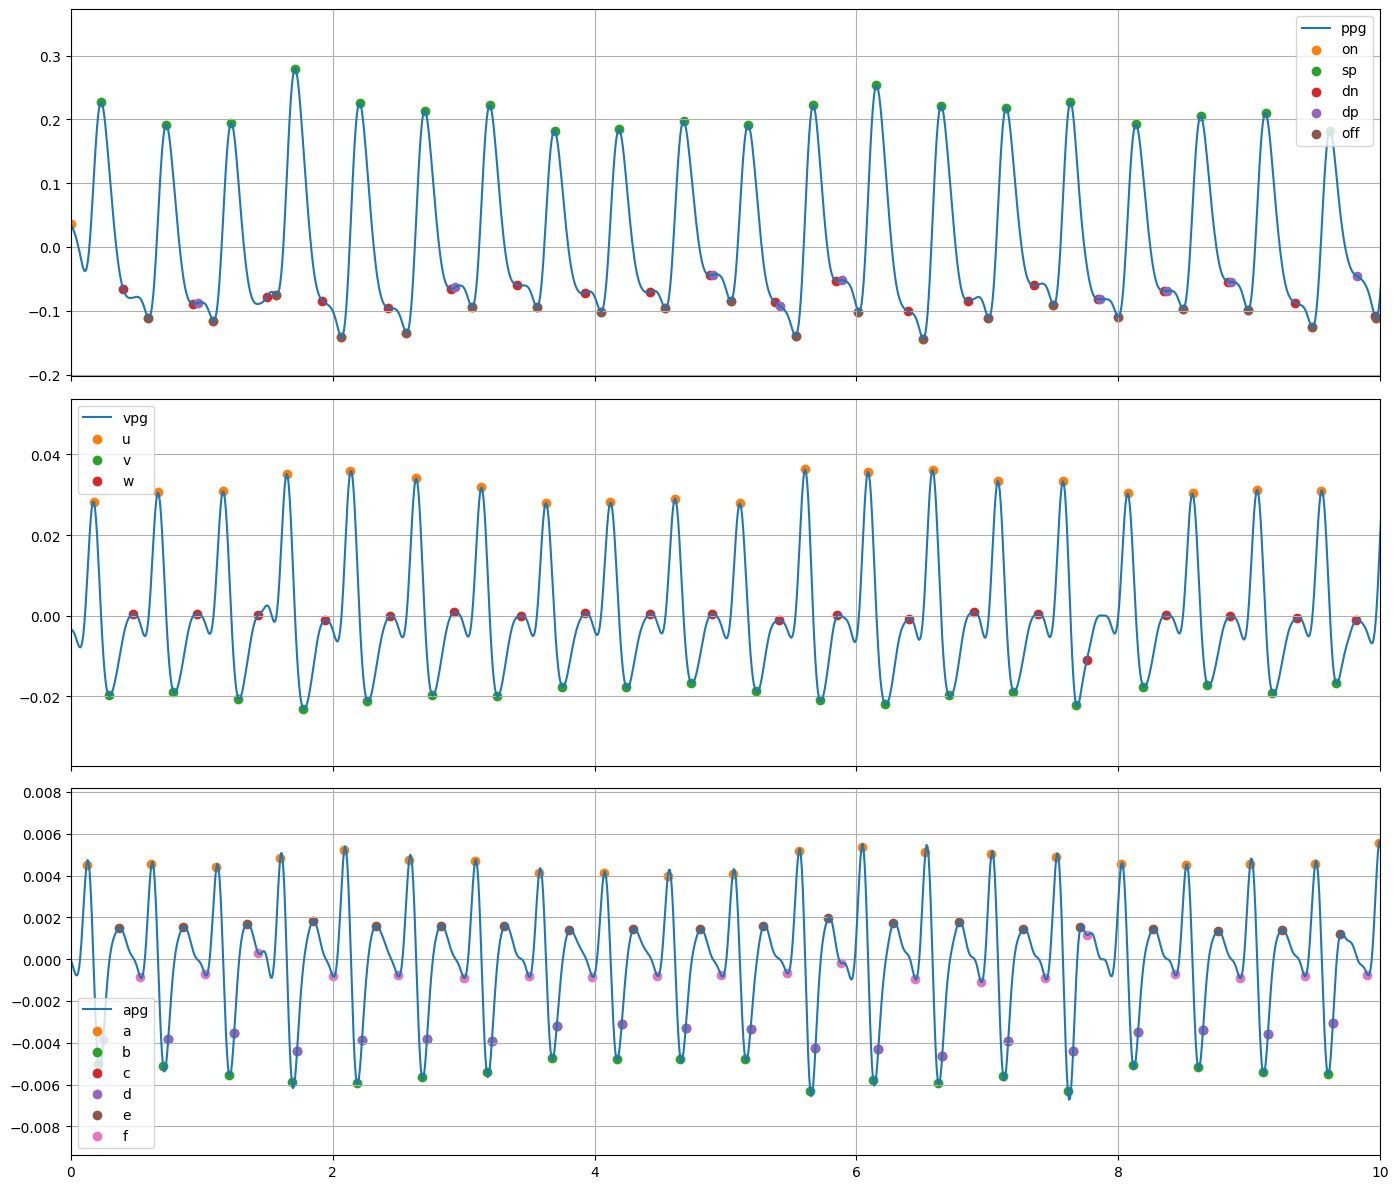

In [21]:
def plot_column(t: np.typing.ArrayLike, s: np.typing.ArrayLike, df: pd.DataFrame, col: str, ax: plt.Axes, color: str):
    indices = df[col].dropna()
    ax.scatter(t[indices], s[indices], color=color)

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(14, 12))
axes: tuple[plt.Axes]

axes[0].plot(t, s.ppg, color='C0')
axes[1].plot(t, s.vpg, color='C0')
axes[2].plot(t, s.apg, color='C0')

df_fp = fp.get_fp()

plot_column(t, s.ppg, df_fp, 'on', axes[0], color='C1')
plot_column(t, s.ppg, df_fp, 'sp', axes[0], color='C2')
plot_column(t, s.ppg, df_fp, 'dn', axes[0], color='C3')
plot_column(t, s.ppg, df_fp, 'dp', axes[0], color='C4')
plot_column(t, s.ppg, df_fp, 'off', axes[0], color='C5')

axes[0].legend(['ppg', 'on', 'sp', 'dn', 'dp', 'off'])

plot_column(t, s.vpg, df_fp, 'u', axes[1], color='C1')
plot_column(t, s.vpg, df_fp, 'v', axes[1], color='C2')
plot_column(t, s.vpg, df_fp, 'w', axes[1], color='C3')

axes[1].legend(['vpg', 'u', 'v', 'w'])

plot_column(t, s.apg, df_fp, 'a', axes[2], color='C1')
plot_column(t, s.apg, df_fp, 'b', axes[2], color='C2')
plot_column(t, s.apg, df_fp, 'c', axes[2], color='C3')
plot_column(t, s.apg, df_fp, 'd', axes[2], color='C4')
plot_column(t, s.apg, df_fp, 'e', axes[2], color='C5')
plot_column(t, s.apg, df_fp, 'f', axes[2], color='C6')

axes[2].legend(['apg', 'a', 'b', 'c', 'd', 'e', 'f'])

axes[0].grid(True)
axes[1].grid(True)
axes[2].grid(True)

fig.tight_layout()

plt.xlim(0, 10)